# The Lifecycle of a Plot

📄 Source: https://matplotlib.org/stable/tutorials/lifecycle.html

One visualization from start to finish: raw data → bar chart → styled → customised → combined with extra elements → saved to disk. Everything uses the **object-oriented** interface (`fig, ax`).

(The tutorial is based on Chris Moffitt's blog post *Effective Matplotlib*.)

## Our data

Sales information for a number of companies.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

print("matplotlib", mpl.__version__)

data = {'Barton LLC': 109438.50,
        'Frami, Hills and Schmidt': 103569.59,
        'Fritsch, Russel and Anderson': 112214.71,
        'Jerde-Hilpert': 112591.43,
        'Keeling LLC': 100934.30,
        'Koepp Ltd': 103660.54,
        'Kulas Inc': 137351.96,
        'Trantow-Barrows': 123381.38,
        'White-Trantow': 135841.99,
        'Will LLC': 104437.60}
group_data = list(data.values())   # the revenues (bar lengths)
group_names = list(data.keys())    # the company names (bar labels)
group_mean = np.mean(group_data)   # used later for a reference line

matplotlib 3.11.2


## Getting started

This data is naturally a bar chart with one bar per company. With the OO approach we first create a `Figure` (the canvas) and an `Axes` (the part of the canvas where this visualization lives).

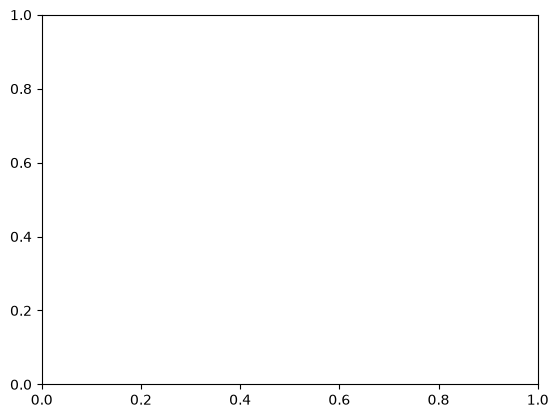

In [2]:
fig, ax = plt.subplots()   # an empty Figure with one empty Axes

Now that we have an Axes, we can plot on it. `barh` = horizontal bars, which suits long category names.

<BarContainer object of 10 artists>

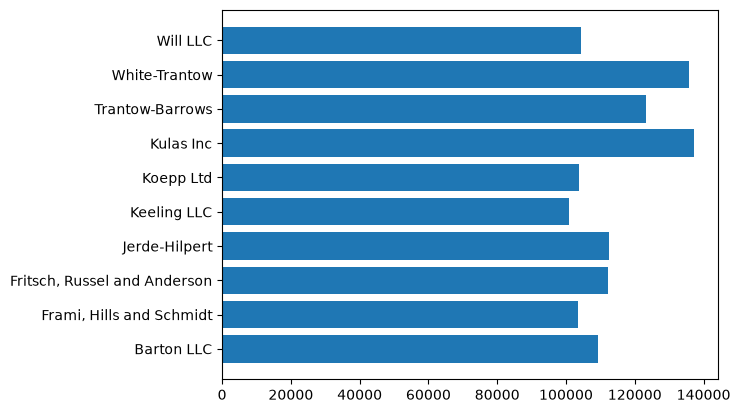

In [3]:
fig, ax = plt.subplots()
ax.barh(group_names, group_data)

## Controlling the style

Matplotlib ships many styles. List them with `plt.style.available`:

In [4]:
print(plt.style.available)

['Solarize_Light2', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'petroff6', 'petroff8', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [5]:
# Activate a style. NOTE: this changes rcParams for every plot after this line in this notebook.
plt.style.use('fivethirtyeight')

<BarContainer object of 10 artists>

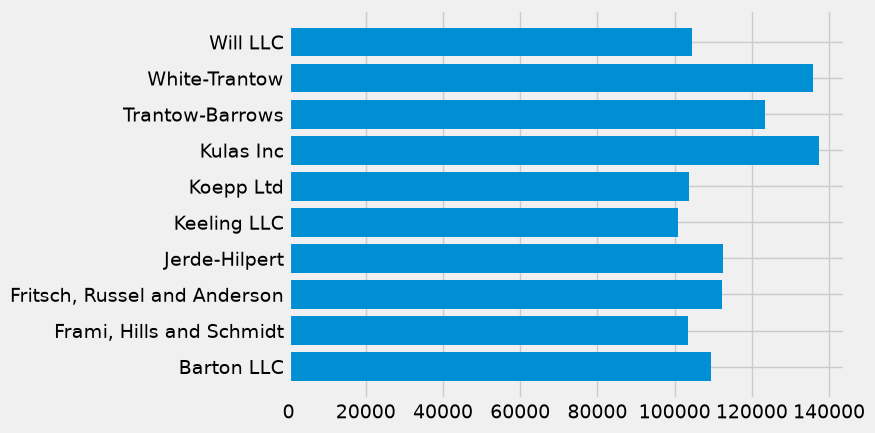

In [6]:
# Remake the plot with the new style
fig, ax = plt.subplots()
ax.barh(group_names, group_data)

The style controls many things: colours, line widths, backgrounds, etc.

## Customizing the plot

Now fine-tune it for print. First, rotate the x tick labels so they read better. We get them with `ax.get_xticklabels()`:

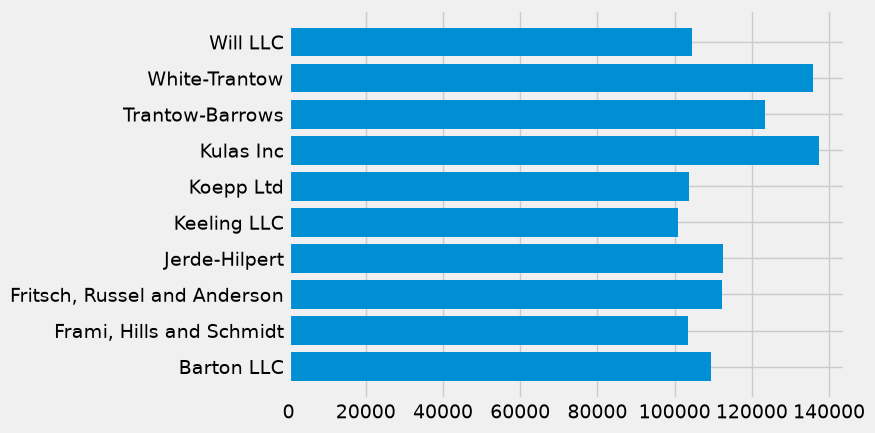

In [7]:
fig, ax = plt.subplots()
ax.barh(group_names, group_data)
labels = ax.get_xticklabels()   # a list of Text artists

`plt.setp` sets a property on **many** artists at once:

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

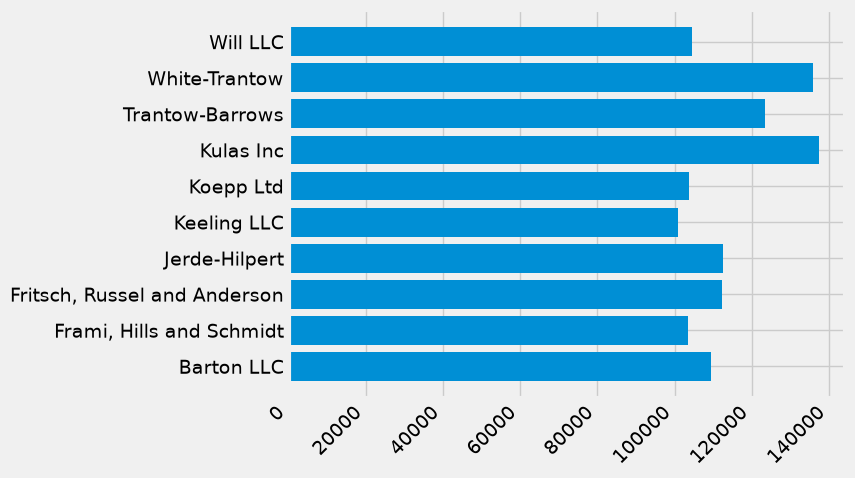

In [8]:
fig, ax = plt.subplots()
ax.barh(group_names, group_data)
labels = ax.get_xticklabels()
plt.setp(labels, rotation=45, horizontalalignment='right')   # rotate every tick label

Some labels are now cut off at the bottom. Setting the rcParam `figure.autolayout` makes Matplotlib leave room for them automatically.

(Today you would normally pass `layout="constrained"` to `plt.subplots()` instead, see notebook 04.)

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

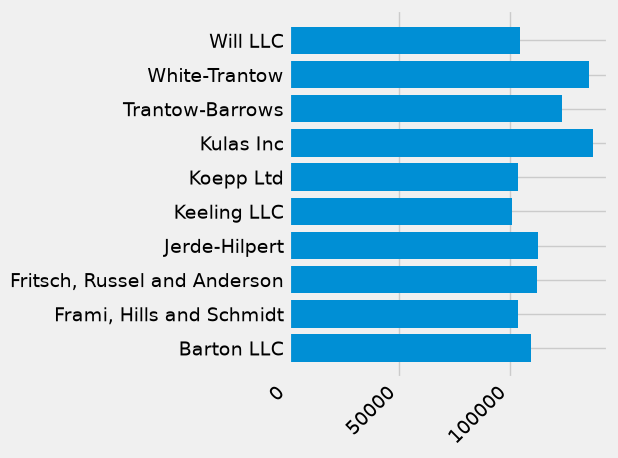

In [9]:
plt.rcParams.update({'figure.autolayout': True})   # auto-make room for labels on every new figure

fig, ax = plt.subplots()
ax.barh(group_names, group_data)
labels = ax.get_xticklabels()
plt.setp(labels, rotation=45, horizontalalignment='right')

Next, add labels. With the OO interface, `ax.set(...)` sets several Axes properties in one call:

[(-10000.0, 140000.0),
 Text(0.5, 0, 'Total Revenue'),
 Text(0, 0.5, 'Company'),
 Text(0.5, 1.0, 'Company Revenue')]

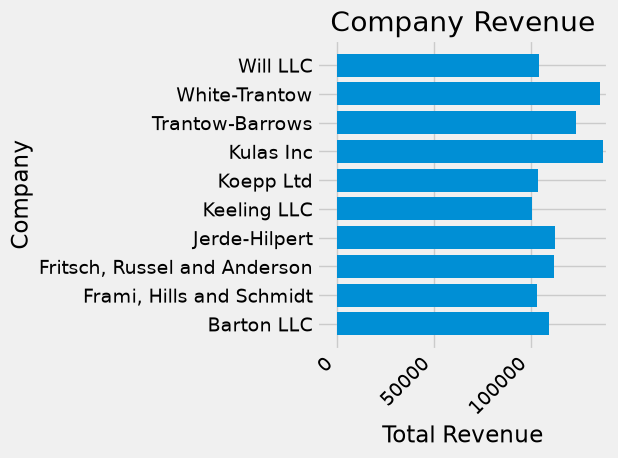

In [10]:
fig, ax = plt.subplots()
ax.barh(group_names, group_data)
labels = ax.get_xticklabels()
plt.setp(labels, rotation=45, horizontalalignment='right')
ax.set(xlim=(-10000, 140000), xlabel='Total Revenue', ylabel='Company',
       title='Company Revenue')   # limits, axis labels and title in one call

Change the figure size with `figsize=`.

> **Note:** NumPy indexing is (row, column), but `figsize` is **(width, height)** in inches.

[(-10000.0, 140000.0),
 Text(0.5, 0, 'Total Revenue'),
 Text(0, 0.5, 'Company'),
 Text(0.5, 1.0, 'Company Revenue')]

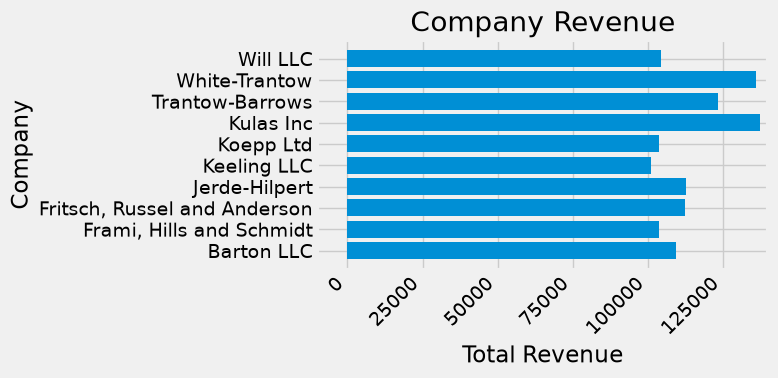

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))   # 8 inches wide, 4 inches tall
ax.barh(group_names, group_data)
labels = ax.get_xticklabels()
plt.setp(labels, rotation=45, horizontalalignment='right')
ax.set(xlim=(-10000, 140000), xlabel='Total Revenue', ylabel='Company',
       title='Company Revenue')

Tick labels can be formatted by a **function**. Given to `Axis.set_major_formatter`, Matplotlib wraps it in a `ticker.FuncFormatter` automatically.
The function receives `x` (the tick value) and `pos` (the tick position). Both arguments are required, even if we only use `x`.

In [12]:
def currency(x, pos):
    """The two arguments are the value and tick position"""
    if x >= 1e6:
        s = f'${x*1e-6:1.1f}M'   # 1,200,000 -> $1.2M
    else:
        s = f'${x*1e-3:1.0f}K'   # 125,000   -> $125K
    return s

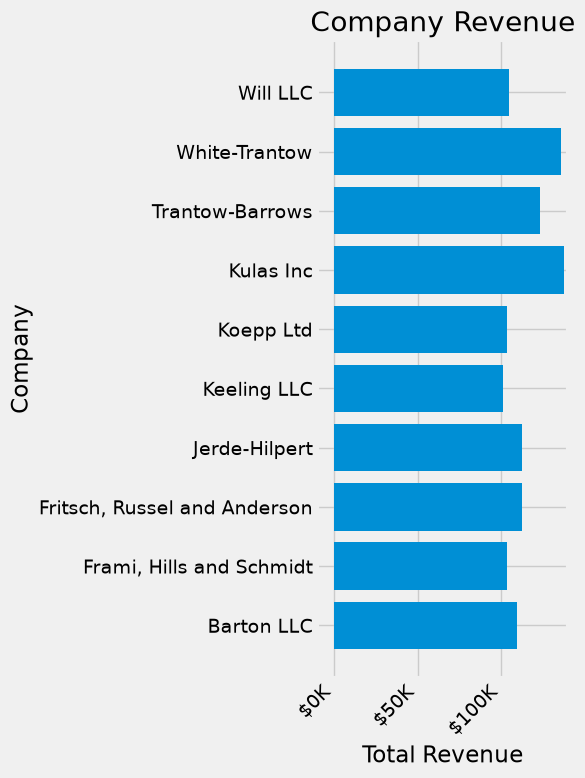

In [13]:
fig, ax = plt.subplots(figsize=(6, 8))
ax.barh(group_names, group_data)
labels = ax.get_xticklabels()
plt.setp(labels, rotation=45, horizontalalignment='right')

ax.set(xlim=(-10000, 140000), xlabel='Total Revenue', ylabel='Company',
       title='Company Revenue')
ax.xaxis.set_major_formatter(currency)   # use our function for the x tick labels

## Combining multiple visualizations

You can draw several plot elements on the same Axes: just call another plotting method on it.
Here: a dashed mean line (`axvline`) and a "New Company" note next to three bars (`ax.text`).

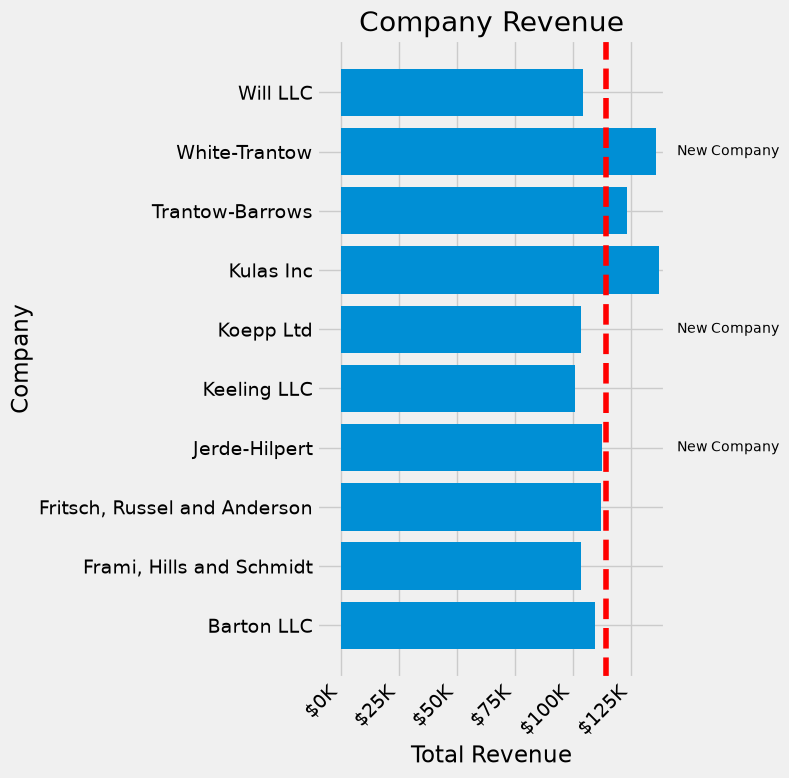

In [14]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(group_names, group_data)
labels = ax.get_xticklabels()
plt.setp(labels, rotation=45, horizontalalignment='right')

# Add a vertical line, here we set the style in the function call
ax.axvline(group_mean, ls='--', color='r')

# Annotate new companies (bars 3, 5 and 8, counted from the bottom)
for group in [3, 5, 8]:
    ax.text(145000, group, "New Company", fontsize=10,
            verticalalignment="center")

# Now we move our title up since it's getting a little cramped
ax.title.set(y=1.05)

ax.set(xlim=(-10000, 140000), xlabel='Total Revenue', ylabel='Company',
       title='Company Revenue')
ax.xaxis.set_major_formatter(currency)
ax.set_xticks([0, 25e3, 50e3, 75e3, 100e3, 125e3])   # choose exactly which ticks to show
fig.subplots_adjust(right=.1)

plt.show()

## Saving our plot

List the file formats this canvas can save to:

In [15]:
print(fig.canvas.get_supported_filetypes())

{'eps': 'Encapsulated Postscript', 'gif': 'Graphics Interchange Format', 'jpg': 'Joint Photographic Experts Group', 'jpeg': 'Joint Photographic Experts Group', 'pdf': 'Portable Document Format', 'pgf': 'PGF code for LaTeX', 'png': 'Portable Network Graphics', 'ps': 'Postscript', 'raw': 'Raw RGBA bitmap', 'rgba': 'Raw RGBA bitmap', 'svg': 'Scalable Vector Graphics', 'svgz': 'Scalable Vector Graphics', 'tif': 'Tagged Image File Format', 'tiff': 'Tagged Image File Format', 'webp': 'WebP Image Format', 'avif': 'AV1 Image File Format'}


Save with `fig.savefig(...)`. Useful flags:

* `transparent=True` makes the background transparent (if the format supports it).
* `dpi=80` controls the resolution (dots per inch). Use 300 for print/reports.
* `bbox_inches="tight"` trims the saved image to the plot.

The docs leave this line commented out. Here it is run for real, saving into the module's `Figures/` folder.

In [16]:
from pathlib import Path

out_dir = Path("../Figures")
out_dir.mkdir(exist_ok=True)   # create the folder if it doesn't exist yet

fig.savefig(out_dir / 'sales.png', transparent=False, dpi=80, bbox_inches="tight")
print("saved:", (out_dir / 'sales.png').resolve().name)

saved: sales.png


## Key takeaways

- Build a chart in layers on **one** `ax`: data → style → labels/limits (`ax.set`) → formatting → extra elements → save.
- `plt.style.use(...)` and `plt.rcParams` change **global** defaults for the rest of the session.
- `figsize=(width, height)` in inches.
- Tick labels can be formatted with a plain function `f(x, pos)` via `ax.xaxis.set_major_formatter`.
- Save with `fig.savefig(path, dpi=..., bbox_inches="tight")`.